# Random Forest — Wind Speed Forecasting
## Variable Set 2

In [ ]:
# =============================================================================
# INSTALLING PACKAGES
# =============================================================================
# !pip install statsmodels optuna tabulate gdown

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.7 MB/s eta 0:00:00


In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard libraries
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap

# Scikit-learn: preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import model_selection, metrics, preprocessing

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)

# Scikit-learn: models & metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy
from statsmodels.graphics.gofplots import qqplot

# Tabulate
from tabulate import tabulate

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna trial logs

# Google Drive download
import gdown

# Global random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                            mean_absolute_percentage_error, r2_score)
import pandas as pd

# Load data from the new Google Drive link
file_id = "1pI2WC2uOQARK3ayA6H4c1Eu2IRqURXbR"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())

            WS10M_lag1     RH  MIN_TEMP   PREC    WD_sin    WD_cos  AVG_TEMP  \
Date                                                                           
2013-01-03        4.25  86.26     23.42  13.42  0.439939  0.898028      26.4   
2013-01-04        4.75  86.31     22.93   8.79  0.424199  0.905569      25.1   
2013-01-05        5.74  86.88     22.17   2.60  0.563526  0.826098      26.9   
2013-01-06        5.79  88.09     23.47   1.65  0.460200  0.887815      27.3   
2013-01-07        4.52  93.04     24.04  27.41  0.368125  0.929776      25.9   

            WS10M_lag2  SURF_PRESSSURE  MAX_TEMP  RH_lag1  WD_sin_lag1  \
Date                                                                     
2013-01-03        3.99           99.68     28.38    86.19     0.500000   
2013-01-04        4.25           99.65     27.58    86.26     0.439939   
2013-01-05        4.75           99.50     26.16    86.31     0.424199   
2013-01-06        5.74           99.47     27.75    86.88     0.56352

In [ ]:
# =============================================================================
# TRAIN / TEST SPLIT  (80% train — 20% test, temporal order preserved)
# =============================================================================
## Data Sets

# Define features and target
X = df.drop(columns=['WS10M'])   # Features (lagged variables)
y = df['WS10M']                  # Target variable (wind speed)

numerical_cols = df.columns

# Define the split index — 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

# Training set
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing set
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("X_train:\n", X_train.head())
print("y_train:\n", y_train.head())
print("X_test:\n",  X_test.head())
print("y_test:\n",  y_test.head())

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train:
             WS10M_lag1     RH  MIN_TEMP   PREC    WD_sin    WD_cos  AVG_TEMP  \
Date                                                                           
2013-01-03        4.25  86.26     23.42  13.42  0.439939  0.898028      26.4   
2013-01-04        4.75  86.31     22.93   8.79  0.424199  0.905569      25.1   
2013-01-05        5.74  86.88     22.17   2.60  0.563526  0.826098      26.9   
2013-01-06        5.79  88.09     23.47   1.65  0.460200  0.887815      27.3   
2013-01-07        4.52  93.04     24.04  27.41  0.368125  0.929776      25.9   

            WS10M_lag2  SURF_PRESSSURE  MAX_TEMP  RH_lag1  WD_sin_lag1  \
Date                                                                     
2013-01-03        3.99           99.68     28.38    86.19     0.500000   
2013-01-04        4.25           99.65     27.58    86.26     0.439939   
2013-01-05        4.75           99.50     26.16    86.31     0.424199   
2013-01-06        5.74           99.47     27.75    86.88  

## Section 1 — Original Model (No Hyperparameter Optimisation)
TimeSeriesSplit cross-validation applied on training data only.

In [ ]:
# =============================================================================
# SECTION 1 — ORIGINAL MODEL  (No Hyperparameter Optimisation)
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Original

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)

# Initialize TimeSeriesSplit with desired number of splits (e.g., 5)
tscv = TimeSeriesSplit(n_splits=5)

# Lists to store evaluation metrics for each fold
train_mse_list,  test_mse_list  = [], []
train_mae_list,  test_mae_list  = [], []
train_rmse_list, test_rmse_list = [], []
train_mape_list, test_mape_list = [], []
train_r2_list,   test_r2_list   = [], []

# Time series cross-validation loop on training data
# NOTE: X_fold_train / X_fold_val are CV fold splits of X_train only.
#       They do NOT overwrite the original 80/20 X_train / X_test splits.
for fold_train_idx, fold_val_idx in tscv.split(X_train):
    # Split training data into fold train and fold validation sets
    X_fold_train = X_train.iloc[fold_train_idx]
    X_fold_val   = X_train.iloc[fold_val_idx]
    y_fold_train = y_train.iloc[fold_train_idx]
    y_fold_val   = y_train.iloc[fold_val_idx]

    # Train the model on the fold training data
    rf.fit(X_fold_train, y_fold_train)

    # Make predictions
    y_fold_train_pred = rf.predict(X_fold_train)
    y_fold_val_pred   = rf.predict(X_fold_val)

    # Calculate evaluation metrics
    fold_train_mse  = mean_squared_error(y_fold_train, y_fold_train_pred)
    fold_val_mse    = mean_squared_error(y_fold_val,   y_fold_val_pred)
    fold_train_mae  = mean_absolute_error(y_fold_train, y_fold_train_pred)
    fold_val_mae    = mean_absolute_error(y_fold_val,   y_fold_val_pred)
    fold_train_rmse = np.sqrt(fold_train_mse)
    fold_val_rmse   = np.sqrt(fold_val_mse)
    fold_train_mape = np.mean(np.abs((y_fold_train - y_fold_train_pred) / np.maximum(y_fold_train, 1e-8))) * 100
    fold_val_mape   = np.mean(np.abs((y_fold_val   - y_fold_val_pred)   / np.maximum(y_fold_val,   1e-8))) * 100
    fold_train_r2   = r2_score(y_fold_train, y_fold_train_pred)
    fold_val_r2     = r2_score(y_fold_val,   y_fold_val_pred)

    # Append results for each fold
    train_mse_list.append(fold_train_mse);   test_mse_list.append(fold_val_mse)
    train_mae_list.append(fold_train_mae);   test_mae_list.append(fold_val_mae)
    train_rmse_list.append(fold_train_rmse); test_rmse_list.append(fold_val_rmse)
    train_mape_list.append(fold_train_mape); test_mape_list.append(fold_val_mape)
    train_r2_list.append(fold_train_r2);     test_r2_list.append(fold_val_r2)

# Calculate average metrics over all CV folds
Original_CV_Train_MSE  = np.mean(train_mse_list)
Original_CV_Test_MSE   = np.mean(test_mse_list)
Original_CV_Train_MAE  = np.mean(train_mae_list)
Original_CV_Test_MAE   = np.mean(test_mae_list)
Original_CV_Train_RMSE = np.mean(train_rmse_list)
Original_CV_Test_RMSE  = np.mean(test_rmse_list)
Original_CV_Train_MAPE = np.mean(train_mape_list)
Original_CV_Test_MAPE  = np.mean(test_mape_list)
Original_CV_Train_R2   = np.mean(train_r2_list)
Original_CV_Test_R2    = np.mean(test_r2_list)

print(f"\n📊 Cross-Validated Average Metrics (on training data folds):")
print(f"Train MSE:  {Original_CV_Train_MSE:.4f},  Val MSE:  {Original_CV_Test_MSE:.4f}")
print(f"Train MAE:  {Original_CV_Train_MAE:.4f},  Val MAE:  {Original_CV_Test_MAE:.4f}")
print(f"Train RMSE: {Original_CV_Train_RMSE:.4f}, Val RMSE: {Original_CV_Test_RMSE:.4f}")
print(f"Train MAPE: {Original_CV_Train_MAPE:.2f}%, Val MAPE: {Original_CV_Test_MAPE:.2f}%")
print(f"Train R²:   {Original_CV_Train_R2:.4f},  Val R²:   {Original_CV_Test_R2:.4f}")

# --- Optimal performance: refit on full X_train, evaluate on held-out X_test ---
rf_original_final = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
rf_original_final.fit(X_train, y_train)

y_train_pred_original = rf_original_final.predict(X_train)
y_test_pred_original  = rf_original_final.predict(X_test)

Original_Train_MSE  = mean_squared_error(y_train,  y_train_pred_original)
Original_Test_MSE   = mean_squared_error(y_test,   y_test_pred_original)
Original_Train_MAE  = mean_absolute_error(y_train, y_train_pred_original)
Original_Test_MAE   = mean_absolute_error(y_test,  y_test_pred_original)
Original_Train_RMSE = np.sqrt(Original_Train_MSE)
Original_Test_RMSE  = np.sqrt(Original_Test_MSE)
Original_Train_MAPE = np.mean(np.abs((y_train - y_train_pred_original) / np.maximum(y_train, 1e-8))) * 100
Original_Test_MAPE  = np.mean(np.abs((y_test  - y_test_pred_original)  / np.maximum(y_test,  1e-8))) * 100
Original_Train_R2   = r2_score(y_train, y_train_pred_original)
Original_Test_R2    = r2_score(y_test,  y_test_pred_original)

print(f"\n📊 Original Model — Optimal Performance (full train → held-out test):")
print(f"Train MSE:  {Original_Train_MSE:.4f},  Test MSE:  {Original_Test_MSE:.4f}")
print(f"Train MAE:  {Original_Train_MAE:.4f},  Test MAE:  {Original_Test_MAE:.4f}")
print(f"Train RMSE: {Original_Train_RMSE:.4f}, Test RMSE: {Original_Test_RMSE:.4f}")
print(f"Train MAPE: {Original_Train_MAPE:.2f}%, Test MAPE: {Original_Test_MAPE:.2f}%")
print(f"Train R²:   {Original_Train_R2:.4f},  Test R²:   {Original_Test_R2:.4f}")


📊 Cross-Validated Average Metrics (on training data folds):
Train MSE:  0.0672,  Val MSE:  0.5641
Train MAE:  0.1995,  Val MAE:  0.5698
Train RMSE: 0.2593, Val RMSE: 0.7509
Train MAPE: 5.70%, Val MAPE: 16.23%
Train R²:   0.9725,  Val R²:   0.7698

📊 Original Model — Optimal Performance (full train → held-out test):
Train MSE:  0.0708,  Test MSE:  0.5846
Train MAE:  0.2011,  Test MAE:  0.5792
Train RMSE: 0.2661, Test RMSE: 0.7646
Train MAPE: 5.64%, Test MAPE: 15.91%
Train R²:   0.9719,  Test R²:   0.7576


In [ ]:
# Assuming X_train and X_test have datetime index, extract the datetime values
train_dates = X_train.index
test_dates  = X_test.index

# Create a time series plot with actual and predicted values for training and test sets
fig = go.Figure()

# Plot Y_train (Actual values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train,              mode='lines', name='Y Train',           line=dict(color='blue')))
# Plot Y_test (Actual values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test,               mode='lines', name='Y Test',            line=dict(color='green')))
# Plot Y_train_predicted (Predicted values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train_pred_original, mode='lines', name='Y Train Predicted', line=dict(color='orange', dash='dot')))
# Plot Y_test_predicted (Predicted values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test_pred_original,  mode='lines', name='Y Test Predicted',  line=dict(color='red',    dash='dot')))

# Customize the layout of the plot
fig.update_layout(
    title="Original Model — Actual vs Predicted Values",
    xaxis_title="Date",
    yaxis_title="Wind Speed (WS10M)",
    template="plotly_white"
)
fig.show()

## Section 2 — Grid Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

In [ ]:
# =============================================================================
# SECTION 2 — GRID SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Grid Search CV Hyper Parameter Tuning

# Define parameter grid (bootstrap removed)
param_grid = {
    'n_estimators':      [100, 150, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]   # Valid options only
}

# Initialize RandomForestRegressor
rf_grid = RandomForestRegressor(random_state=RANDOM_SEED)

# TimeSeriesSplit ensures training precedes testing in time
tscv = TimeSeriesSplit(n_splits=5)

# Initialize GridSearchCV — fitted on X_train only (no test set exposure)
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    refit=True    # Refit best model on full X_train automatically
)

# Fit the model with GridSearchCV on training data only
grid_search.fit(X_train, y_train)

# Extract best parameters and model
grid_best_params = grid_search.best_params_
grid_best_score  = grid_search.best_score_
best_rf_grid     = grid_search.best_estimator_

print(f"\n✅ Best Hyperparameters: {grid_best_params}")
print(f"📉 Best CV Score (Negative MSE): {grid_best_score:.4f}")

# --- Optimal performance: predict on full X_train and X_test ---
y_train_pred_grid = best_rf_grid.predict(X_train)
y_test_pred_grid  = best_rf_grid.predict(X_test)

# Evaluate performance
grid_train_mse  = mean_squared_error(y_train,  y_train_pred_grid)
grid_test_mse   = mean_squared_error(y_test,   y_test_pred_grid)
grid_train_mae  = mean_absolute_error(y_train, y_train_pred_grid)
grid_test_mae   = mean_absolute_error(y_test,  y_test_pred_grid)
grid_train_rmse = np.sqrt(grid_train_mse)
grid_test_rmse  = np.sqrt(grid_test_mse)
# Handle division by zero in MAPE
grid_train_mape = np.mean(np.abs((y_train - y_train_pred_grid) / np.maximum(y_train, 1e-8))) * 100
grid_test_mape  = np.mean(np.abs((y_test  - y_test_pred_grid)  / np.maximum(y_test,  1e-8))) * 100
grid_train_r2   = r2_score(y_train, y_train_pred_grid)
grid_test_r2    = r2_score(y_test,  y_test_pred_grid)

# Output results
print(f"\n📊 Grid Search — Optimal Performance:")
print(f"Train MSE:  {grid_train_mse:.4f},  Test MSE:  {grid_test_mse:.4f}")
print(f"Train MAE:  {grid_train_mae:.4f},  Test MAE:  {grid_test_mae:.4f}")
print(f"Train RMSE: {grid_train_rmse:.4f}, Test RMSE: {grid_test_rmse:.4f}")
print(f"Train MAPE: {grid_train_mape:.2f}%, Test MAPE: {grid_test_mape:.2f}%")
print(f"Train R²:   {grid_train_r2:.4f},  Test R²:   {grid_test_r2:.4f}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

✅ Best Hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
📉 Best CV Score (Negative MSE): -0.5572

📊 Grid Search — Optimal Performance:
Train MSE:  0.1633,  Test MSE:  0.5730
Train MAE:  0.2949,  Test MAE:  0.5778
Train RMSE: 0.4041, Test RMSE: 0.7570
Train MAPE: 8.28%, Test MAPE: 15.85%
Train R²:   0.9352,  Test R²:   0.7624


Test MSE:  0.6207
Test MAE:  0.6090
Test RMSE: 0.7878
Test MAPE: 17.0040%


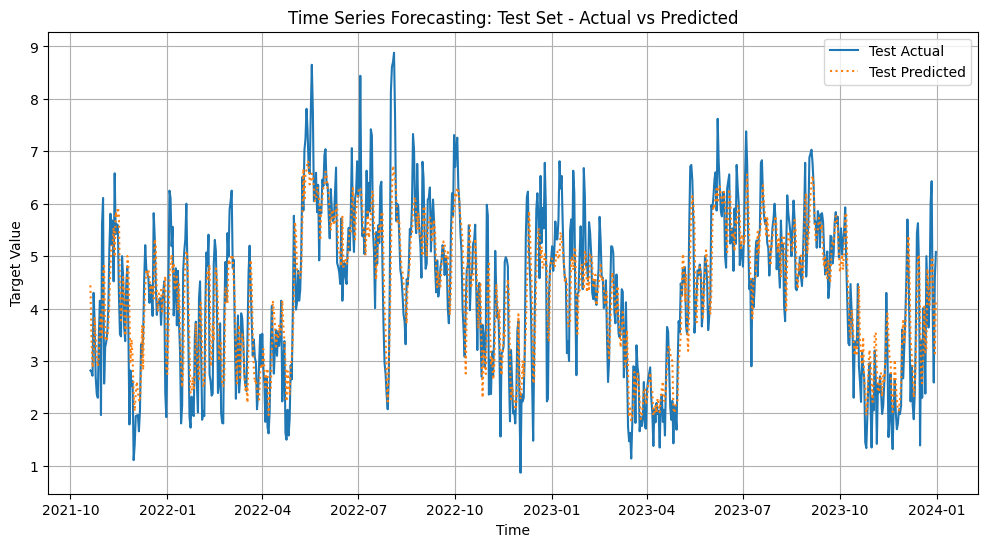

In [ ]:
# Assuming X_train and X_test have datetime index, extract the datetime values
train_dates = X_train.index
test_dates  = X_test.index

# Create a time series plot with actual and predicted values for training and test sets
fig = go.Figure()

# Plot Y_train (Actual values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train,           mode='lines', name='Y Train',           line=dict(color='blue')))
# Plot Y_test (Actual values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test,            mode='lines', name='Y Test',            line=dict(color='green')))
# Plot Y_train_predicted (Predicted values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train_pred_grid, mode='lines', name='Y Train Predicted', line=dict(color='orange', dash='dot')))
# Plot Y_test_predicted (Predicted values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test_pred_grid,  mode='lines', name='Y Test Predicted',  line=dict(color='red',    dash='dot')))

# Customize the layout of the plot
fig.update_layout(
    title="Grid Search CV — Actual vs Predicted Values",
    xaxis_title="Date",
    yaxis_title="Wind Speed (WS10M)",
    template="plotly_white"
)
fig.show()

import matplotlib.pyplot as plt

# Fit the Random Forest model with the best grid-search tuned parameters
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=10,
    random_state=RANDOM_SEED
)

# Train the model
rf_tuned.fit(X_train, y_train)

# Make predictions on the test set
y_test_pred_tuned = rf_tuned.predict(X_test)

# Calculate evaluation metrics
tuned_test_mse  = mean_squared_error(y_test, y_test_pred_tuned)
tuned_test_mae  = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_test_rmse = np.sqrt(tuned_test_mse)
# Avoid division by zero in MAPE
tuned_test_mape = np.mean(np.abs((y_test - y_test_pred_tuned) / np.maximum(y_test, 1e-8))) * 100

# Print performance metrics
print(f"Test MSE:  {tuned_test_mse:.4f}")
print(f"Test MAE:  {tuned_test_mae:.4f}")
print(f"Test RMSE: {tuned_test_rmse:.4f}")
print(f"Test MAPE: {tuned_test_mape:.4f}%")

# Extract test set datetime index
test_dates = X_test.index

# Plot actual vs predicted values for test set
fig = go.Figure()

# Plot actual test values
fig.add_trace(go.Scatter(x=test_dates, y=y_test,            mode='lines', name='Actual Test',    line=dict(color='green')))
# Plot predicted test values
fig.add_trace(go.Scatter(x=test_dates, y=y_test_pred_tuned, mode='lines', name='Predicted Test', line=dict(color='red', dash='dot')))

# Customize layout
fig.update_layout(
    title="Manually Tuned RF — Actual vs Predicted (Test Set)",
    xaxis_title="Date",
    yaxis_title="Wind Speed (WS10M)",
    template="plotly_white"
)
fig.show()

# Create the matplotlib plot
plt.figure(figsize=(12, 6))

# Plot test actual values
plt.plot(y_test.index, y_test,            label='Test Actual')
# Plot test predicted values
plt.plot(y_test.index, y_test_pred_tuned, label='Test Predicted', linestyle='dotted')

# Customize layout
plt.title("Time Series Forecasting: Test Set - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

## Section 3 — Randomized Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

In [ ]:
# =============================================================================
# SECTION 3 — RANDOMIZED SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
### Random Search CV

# Define the Random Forest Regressor model with fixed random seed
rf_random = RandomForestRegressor(random_state=RANDOM_SEED)

# Define the parameter grid for hyperparameter tuning
# NOTE: 'auto' has been removed — deprecated in recent sklearn versions; 'sqrt' is equivalent
param_grid_random = {
    'n_estimators':      [50, 100, 150, 200],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf':  [1, 2, 4, 7],
    'max_features':      ['sqrt', 'log2', None]   # 'auto' removed (deprecated)
}

# Set up the TimeSeriesSplit object for time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Set up RandomizedSearchCV with random_state and TimeSeriesSplit
# Fitted on X_train only (no test set exposure)
random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=param_grid_random,
    n_iter=100,
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_SEED,    # Fixed random seed
    refit=True                   # Refit best model on full X_train automatically
)

# Fit the model on training data only
random_search.fit(X_train, y_train)

# Get the best parameters and best estimator
random_best_params = random_search.best_params_
random_best_rf     = random_search.best_estimator_

print(f"Best Parameters: {random_best_params}")

# --- Optimal performance: predict on full X_train and X_test ---
y_train_pred_random = random_best_rf.predict(X_train)
y_test_pred_random  = random_best_rf.predict(X_test)

# Evaluate performance
random_train_mse  = mean_squared_error(y_train,  y_train_pred_random)
random_test_mse   = mean_squared_error(y_test,   y_test_pred_random)
random_train_mae  = mean_absolute_error(y_train, y_train_pred_random)
random_test_mae   = mean_absolute_error(y_test,  y_test_pred_random)
random_train_rmse = np.sqrt(random_train_mse)
random_test_rmse  = np.sqrt(random_test_mse)
random_train_mape = np.mean(np.abs((y_train - y_train_pred_random) / np.maximum(y_train, 1e-8))) * 100
random_test_mape  = np.mean(np.abs((y_test  - y_test_pred_random)  / np.maximum(y_test,  1e-8))) * 100
# R-squared
random_train_r2   = r2_score(y_train, y_train_pred_random)
random_test_r2    = r2_score(y_test,  y_test_pred_random)

# Print metrics
print(f"\n📊 Randomized Search — Optimal Performance:")
print(f"Random Train MSE:  {random_train_mse:.4f},  Random Test MSE:  {random_test_mse:.4f}")
print(f"Random Train MAE:  {random_train_mae:.4f},  Random Test MAE:  {random_test_mae:.4f}")
print(f"Random Train RMSE: {random_train_rmse:.4f}, Random Test RMSE: {random_test_rmse:.4f}")
print(f"Random Train MAPE: {random_train_mape:.2f}%, Random Test MAPE: {random_test_mape:.2f}%")
print(f"Random Train R²:   {random_train_r2:.4f},  Random Test R²:   {random_test_r2:.4f}")

# Create a DataFrame from the random search results
random_search_results = pd.DataFrame(random_search.cv_results_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}

📊 Randomized Search — Optimal Performance:
Random Train MSE:  0.2185,  Random Test MSE:  0.5777
Random Train MAE:  0.3547,  Random Test MAE:  0.5812
Random Train RMSE: 0.4674, Random Test RMSE: 0.7601
Random Train MAPE: 9.83%, Random Test MAPE: 15.97%
Random Train R²:   0.9133,  Random Test R²:   0.7604


In [ ]:
# Assuming X_train and X_test have datetime index, extract the datetime values
train_dates = X_train.index
test_dates  = X_test.index

y_train_pred = y_train_pred_random
y_test_pred  = y_test_pred_random

# Create a time series plot with actual and predicted values for training and test sets
fig = go.Figure()

# Plot Y_train (Actual values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train,      mode='lines', name='Y Train',           line=dict(color='blue')))
# Plot Y_test (Actual values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test,       mode='lines', name='Y Test',            line=dict(color='green')))
# Plot Y_train_predicted (Predicted values for train set)
fig.add_trace(go.Scatter(x=train_dates, y=y_train_pred, mode='lines', name='Y Train Predicted', line=dict(color='orange', dash='dot')))
# Plot Y_test_predicted (Predicted values for test set)
fig.add_trace(go.Scatter(x=test_dates,  y=y_test_pred,  mode='lines', name='Y Test Predicted',  line=dict(color='red',    dash='dot')))

# Customize the layout of the plot
fig.update_layout(
    title="Randomized Search CV — Actual vs Predicted Values",
    xaxis_title="Date",
    yaxis_title="Wind Speed (WS10M)",
    template="plotly_white"
)
fig.show()

## Section 4 — Optuna Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix**: Original objective minimized `mean_squared_error(y_test, y_test_pred)` directly — hyperparameters were selected based on held-out test performance (data leakage). Corrected to use `TimeSeriesSplit` CV on `X_train` only inside the objective.

In [ ]:
# =============================================================================
# SECTION 4 — OPTUNA  Hyperparameter Tuning
# FIX: Original objective called rf_model.predict(X_test) and minimized test_mse.
#      This means Optuna selected hyperparameters based on held-out test performance
#      — a direct form of data leakage that invalidates the tuning process.
#      Fixed: CV folds inside the objective use TimeSeriesSplit on X_train only.
# =============================================================================
### Optuna

# Define the objective function for optimisation
def objective(trial):
    # Optimised parameter space (bootstrap removed)
    n_estimators      = trial.suggest_int('n_estimators',      50,  200, step=50)
    max_depth         = trial.suggest_categorical('max_depth',  [None, 10, 20, 30])
    min_samples_split = trial.suggest_int('min_samples_split',  2,   10)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf',   1,   7)
    max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Define the model with the suggested hyperparameters
    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_SEED
    )

    # Use TimeSeriesSplit CV on X_train only — avoids any exposure to held-out X_test
    # FIX: previously X_test was used directly here, causing data leakage
    tscv_optuna     = TimeSeriesSplit(n_splits=5)
    fold_mse_scores = []

    for fold_train_idx, fold_val_idx in tscv_optuna.split(X_train):
        X_fold_tr  = X_train.iloc[fold_train_idx]
        X_fold_val = X_train.iloc[fold_val_idx]
        y_fold_tr  = y_train.iloc[fold_train_idx]
        y_fold_val = y_train.iloc[fold_val_idx]

        rf_model.fit(X_fold_tr, y_fold_tr)
        y_fold_val_pred = rf_model.predict(X_fold_val)
        fold_mse_scores.append(mean_squared_error(y_fold_val, y_fold_val_pred))

    # Return the mean CV MSE across all folds — no test set exposure
    return np.mean(fold_mse_scores)

# Set up the Optuna study using TPE Sampler
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(objective, n_trials=50)

# Get the best parameters found by Optuna
optuna_best_params = study.best_params
print(f"\n✅ Best Parameters Found by Optuna:\n{optuna_best_params}")

# --- Optimal performance: refit on full X_train, evaluate on X_train and X_test ---
best_rf_optuna = RandomForestRegressor(**optuna_best_params, random_state=RANDOM_SEED)
best_rf_optuna.fit(X_train, y_train)

# Make predictions
y_train_pred_optuna = best_rf_optuna.predict(X_train)
y_test_pred_optuna  = best_rf_optuna.predict(X_test)

# Evaluate performance
train_mse_optuna  = mean_squared_error(y_train,  y_train_pred_optuna)
test_mse_optuna   = mean_squared_error(y_test,   y_test_pred_optuna)
train_mae_optuna  = mean_absolute_error(y_train, y_train_pred_optuna)
test_mae_optuna   = mean_absolute_error(y_test,  y_test_pred_optuna)
train_rmse_optuna = np.sqrt(train_mse_optuna)
test_rmse_optuna  = np.sqrt(test_mse_optuna)
# R-squared (coefficient of determination)
train_r2_optuna   = r2_score(y_train, y_train_pred_optuna)
test_r2_optuna    = r2_score(y_test,  y_test_pred_optuna)
# Avoid division by zero in MAPE
train_mape_optuna = np.mean(np.abs((y_train - y_train_pred_optuna) / np.maximum(y_train, 1e-8))) * 100
test_mape_optuna  = np.mean(np.abs((y_test  - y_test_pred_optuna)  / np.maximum(y_test,  1e-8))) * 100

# Print metrics
print("\n📊 Optuna — Optimal Performance:")
print(f"Train MSE:  {train_mse_optuna:.4f},  Test MSE:  {test_mse_optuna:.4f}")
print(f"Train MAE:  {train_mae_optuna:.4f},  Test MAE:  {test_mae_optuna:.4f}")
print(f"Train RMSE: {train_rmse_optuna:.4f}, Test RMSE: {test_rmse_optuna:.4f}")
print(f"Train MAPE: {train_mape_optuna:.2f}%, Test MAPE: {test_mape_optuna:.2f}%")
print(f"Train R²:   {train_r2_optuna:.4f},  Test R²:   {test_r2_optuna:.4f}")

# Create DataFrame from study
optuna_results  = study.trials_dataframe()

# Extract relevant columns (bootstrap removed)
cols_to_extract = [
    'number', 'value',
    'params_n_estimators', 'params_max_depth', 'params_min_samples_split',
    'params_min_samples_leaf', 'params_max_features'
]
optuna_table_df = optuna_results[cols_to_extract].copy()

# Rename for display
optuna_table_df.columns = [
    'Trial', 'CV MSE', 'n_estimators', 'max_depth',
    'min_samples_split', 'min_samples_leaf', 'max_features'
]

# Create Plotly Table
fig_table_optuna = go.Figure(data=[go.Table(
    header=dict(values=list(optuna_table_df.columns),
                fill_color='paleturquoise', align='left'),
    cells=dict(values=[optuna_table_df[col] for col in optuna_table_df.columns],
               fill_color='lavender', align='left')
)])
fig_table_optuna.update_layout(
    title="Optuna Results — Random Forest Hyperparameter Tuning",
    height=600,
    template='plotly_white'
)
fig_table_optuna.show()


✅ Best Parameters Found by Optuna:
{'n_estimators': 150, 'max_depth': None, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': None}

📊 Optuna — Optimal Performance:
Train MSE:  0.1578,  Test MSE:  0.5771
Train MAE:  0.2904,  Test MAE:  0.5802
Train RMSE: 0.3973, Test RMSE: 0.7597
Train MAPE: 8.15%, Test MAPE: 15.93%
Train R²:   0.9374,  Test R²:   0.7607


In [ ]:
# Assuming X_train and X_test have datetime index, extract the datetime values
train_dates = X_train.index
test_dates  = X_test.index

# Create a time series plot with actual and predicted values for training and test sets
fig = go.Figure()

# Plot Y_train
fig.add_trace(go.Scatter(x=train_dates, y=y_train,             mode='lines', name='Y Train',           line=dict(color='blue')))
# Plot Y_test
fig.add_trace(go.Scatter(x=test_dates,  y=y_test,              mode='lines', name='Y Test',            line=dict(color='green')))
# Plot Y_train_predicted
fig.add_trace(go.Scatter(x=train_dates, y=y_train_pred_optuna, mode='lines', name='Y Train Predicted', line=dict(color='orange', dash='dot')))
# Plot Y_test_predicted
fig.add_trace(go.Scatter(x=test_dates,  y=y_test_pred_optuna,  mode='lines', name='Y Test Predicted',  line=dict(color='red',    dash='dot')))

# Customize the layout of the plot
fig.update_layout(
    title="Optuna — Actual vs Predicted Values",
    xaxis_title="Date",
    yaxis_title="Wind Speed (WS10M)",
    template="plotly_white"
)
fig.show()

## Final Comparison Table

In [ ]:
# =============================================================================
# FINAL COMPARISON TABLE
# Optimal train/test performance for each method
# (best model refitted on full X_train, evaluated on held-out X_test)
# =============================================================================

# Define the model evaluation results
results = {
    "Method":         ["Original Model", "Grid Search", "Randomized Search", "Optuna"],

    "Train MSE":      [Original_Train_MSE,  grid_train_mse,  random_train_mse,  train_mse_optuna],
    "Test MSE":       [Original_Test_MSE,   grid_test_mse,   random_test_mse,   test_mse_optuna],

    "Train MAE":      [Original_Train_MAE,  grid_train_mae,  random_train_mae,  train_mae_optuna],
    "Test MAE":       [Original_Test_MAE,   grid_test_mae,   random_test_mae,   test_mae_optuna],

    "Train RMSE":     [Original_Train_RMSE, grid_train_rmse, random_train_rmse, train_rmse_optuna],
    "Test RMSE":      [Original_Test_RMSE,  grid_test_rmse,  random_test_rmse,  test_rmse_optuna],

    "Train MAPE (%)": [Original_Train_MAPE, grid_train_mape, random_train_mape, train_mape_optuna],
    "Test MAPE (%)":  [Original_Test_MAPE,  grid_test_mape,  random_test_mape,  test_mape_optuna],

    "Train R²":       [Original_Train_R2,   grid_train_r2,   random_train_r2,   train_r2_optuna],
    "Test R²":        [Original_Test_R2,    grid_test_r2,    random_test_r2,    test_r2_optuna],
}

# Convert dictionary to Pandas DataFrame
df_results = pd.DataFrame(results)

# Print the title
print("\n" + "=" * 50)
print("Variable Set 2 — Random Forest Modelling")
print("(Optimal Train/Test Performance per Method)")
print("=" * 50 + "\n")

# Display the table
print(df_results.to_string(index=False))

# Save the DataFrame to a CSV file
df_results.to_csv("variableSet_2_random_forest_results.csv", index=False)
print("\nResults saved to 'variableSet_2_random_forest_results.csv'")


Variable Set 2 — Random Forest Modelling
(Optimal Train/Test Performance per Method)

           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.070791  0.584600   0.201121  0.579242    0.266065   0.764591        5.643861      15.905031  0.971901 0.757573
      Grid Search   0.163258  0.573037   0.294872  0.577763    0.404052   0.756992        8.284027      15.853839  0.935197 0.762367
Randomized Search   0.218477  0.577718   0.354688  0.581229    0.467415   0.760078        9.825292      15.966390  0.913279 0.760426
           Optuna   0.157818  0.577093   0.290401  0.580248    0.397263   0.759666        8.153760      15.933787  0.937356 0.760686

Results saved to 'variableSet_2_random_forest_results.csv'
